# Оптимизация гибридной энергосистемы: ПВ + ветер + аккумулятор


Все предыдущие занятия были про **предсказание** (выработка, неисправности, ресурс). Финал — про **проектирование**: как из изученных кирпичиков (солнце, ветер, накопитель) собрать систему, которая покрывает нагрузку **с минимальной стоимостью**.

Это другой класс задач — **оптимизация**, а не машинное обучение. Инструмент — линейное программирование (LP) через библиотеку `PuLP`. Мы зададим, во что обходится каждый киловатт мощности и киловатт‑час хранения, и пусть решатель  найдет оптимальный состав и почасовой режим работы.

Для преемственности солнечный профиль берем из реальных данных **Plant_1** (то же занятие про солнце), а ветер и нагрузку моделируем простыми, но реалистичными профилями.

> **Все деньги — в рублях, по ориентирам тарифов и цен РФ (2025–2026).** Тариф сети 9 ₽/кВт·ч (промышленный потребитель), ПВ 60 000 ₽/кВт, ветер 110 000 ₽/кВт, литий‑ионный накопитель 28 000 ₽/кВт·ч. Все цифры вынесены в один блок и легко меняются под свой регион и проект.


## Дорожная карта

| Раздел | Что делаем | Главный вопрос |
|---|---|---|
| 1 | Часовые профили: солнце (Plant_1) + ветер + нагрузка | Когда есть энергия и когда она нужна? |
| 2 | Экономика: цены в ₽ и приведение капзатрат (CRF, LCOE) | Сколько стоит киловатт‑час из каждого источника? |
| 3 | **Что именно мы оптимизируем** — схема, переменные, цель, ограничения | В чём, собственно, оптимизация? |
| 4 | Решение LP + состав, разбор стоимости и энергии, сравнение с «только сеть» | Что выгоднее построить и сколько это экономит? |
| 5 | Диспетчеризация: как система живёт по часам | Как батарея сдвигает энергию во времени? |
| 6 | Чувствительность к цене аккумулятора | Как экономика хранения переворачивает выбор технологий? |
| 7 | Выводы и задания | — |

**Данные:** загрузите в корень Colab файл `Plant_1_Generation_Data.csv` (тот же, что в солнечном занятии). Ветер, нагрузка и все стоимости — иллюстративные модели и параметры, их легко менять под свой кейс.


## 0. Установка и оформление графиков


In [ ]:
!pip install -q pulp


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# единое оформление графиков
plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 110,
    'font.size': 11, 'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.grid': True, 'grid.alpha': 0.25, 'axes.axisbelow': True,
    'axes.spines.top': False, 'axes.spines.right': False,
})

# фирменная палитра источников (используем по всему ноутбуку)
C = {'pv':'#F4A300', 'wind':'#3A86FF', 'batt':'#8338EC',
     'grid':'#E63946', 'load':'#1D1D1D', 'curtail':'#9AA0A6'}

def rub(x):
    """красиво печатать рубли: 78 122 228 -> '78.1 млн ₽'"""
    if abs(x) >= 1e6: return f"{x/1e6:.1f} млн ₽"
    if abs(x) >= 1e3: return f"{x/1e3:.0f} тыс ₽"
    return f"{x:.0f} ₽"


## 1. Профили: солнце, ветер, нагрузка

Всё сводим к **часовому ряду** на один период. Три кривые:

- **Солнце** — реальная выработка Plant_1, нормированная к диапазону 0…1. Это «коэффициент использования» (КИУМ) на каждый установленный кВт ПВ: сколько киловатт реально даёт 1 кВт панелей в данный час.
- **Ветер** — простая модель со средним КИУМ ~0.20 и слабым суточным ходом (чуть сильнее ночью — он **дополняет** дневное солнце). Это ключевая идея гибрида: два источника с разным расписанием закрывают сутки лучше, чем один.
- **Нагрузка** — типовой двугорбый профиль потребления (утренний и вечерний пики), будни выше выходных, в кВт.

Ниже два взгляда на данные: **слева** — как профили выглядят несколько суток подряд (видно фактуру и погодную изменчивость), **справа** — **усреднённый день** (24 часа): здесь наглядно видно, что солнце сосредоточено в полдень, спрос — утром и вечером, и между ними есть разрыв, который и должна закрыть батарея.


Период: 2020-05-15 00:00:00 — 2020-06-17 23:00:00  |  часов: 816  (~34 сут)
Средний КИУМ:  солнце 0.24   ветер 0.20
Нагрузка:  средняя 1383 кВт   пик 2108 кВт


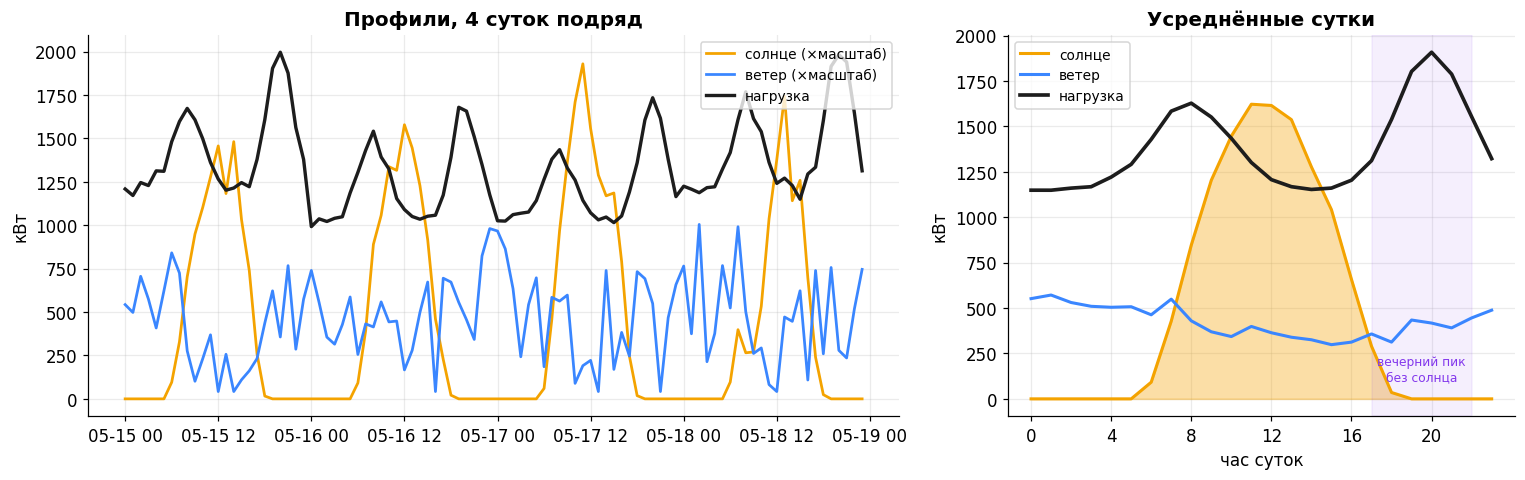

In [ ]:
# --- солнце из реального Plant_1 (часовой коэффициент использования) ---
gen = pd.read_csv("Plant_1_Generation_Data.csv")
gen["DATE_TIME"] = pd.to_datetime(gen["DATE_TIME"], dayfirst=True)
solar_kw = gen.groupby("DATE_TIME")["AC_POWER"].sum().resample("1h").mean()
solar_cf = (solar_kw / solar_kw.max()).clip(0, 1).fillna(0).values
idx = solar_kw.index
H = len(solar_cf)
hours = idx.hour.values

# --- ветер: простая модель (среднее КИУМ ~0.20, слабый суточный ход + шум) ---
rng = np.random.default_rng(0)
wind_cf = np.clip(0.20 + 0.06*np.cos((hours-3)/24*2*np.pi) + rng.normal(0, 0.12, H), 0.02, 1.0)

# --- нагрузка: двугорбый профиль, будни выше выходных, в кВт ---
weekday = (pd.Series(idx.dayofweek).values < 5).astype(float)
shape = 0.6 + 0.25*np.exp(-((hours-8)**2)/8) + 0.4*np.exp(-((hours-20)**2)/6)
load = np.clip(2000*shape*(0.85 + 0.15*weekday)*(1 + rng.normal(0, 0.03, H)), 0, None)

print(f"Период: {idx.min()} — {idx.max()}  |  часов: {H}  (~{H/24:.0f} сут)")
print(f"Средний КИУМ:  солнце {solar_cf.mean():.2f}   ветер {wind_cf.mean():.2f}")
print(f"Нагрузка:  средняя {load.mean():.0f} кВт   пик {load.max():.0f} кВт")

# --- два графика рядом: фрагмент во времени + усреднённые сутки ---
fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 4.5), gridspec_kw={'width_ratios':[1.6,1]})

n = 24*4
sc = load.max()  # масштаб, чтобы КИУМ-кривые читались рядом с нагрузкой
axL.plot(idx[:n], (solar_cf*sc)[:n], color=C['pv'],   lw=1.8, label='солнце (×масштаб)')
axL.plot(idx[:n], (wind_cf*sc)[:n],  color=C['wind'], lw=1.8, label='ветер (×масштаб)')
axL.plot(idx[:n], load[:n],          color=C['load'], lw=2.2, label='нагрузка')
axL.set_ylabel('кВт'); axL.set_title('Профили, 4 суток подряд')
axL.legend(loc='upper right', fontsize=9)

# усреднённый день
def daily_mean(x):
    return pd.Series(x).groupby(hours).mean().reindex(range(24)).values
hh = np.arange(24)
axR.fill_between(hh, 0, daily_mean(solar_cf)*sc, color=C['pv'],  alpha=.35)
axR.plot(hh, daily_mean(solar_cf)*sc, color=C['pv'],   lw=2, label='солнце')
axR.plot(hh, daily_mean(wind_cf)*sc,  color=C['wind'], lw=2, label='ветер')
axR.plot(hh, daily_mean(load),        color=C['load'], lw=2.4, label='нагрузка')
axR.axvspan(17, 22, color=C['batt'], alpha=.08)
axR.text(19.5, axR.get_ylim()[1]*0.05, 'вечерний пик\nбез солнца', ha='center', fontsize=8, color=C['batt'])
axR.set_xlabel('час суток'); axR.set_ylabel('кВт'); axR.set_title('Усреднённые сутки')
axR.set_xticks(range(0,24,4)); axR.legend(loc='upper left', fontsize=9)
plt.tight_layout(); plt.show()


## 2. Экономика: рубли, CRF и стоимость киловатт‑часа

Капитальные затраты (CAPEX) — **разовые**, а годовой счёт за сеть — **ежегодный**. Чтобы сравнивать их в одной размерности, разовый CAPEX превращают в **эквивалентный годовой платёж** через **фактор возврата капитала (CRF)** — как аннуитет по кредиту за срок службы при ставке дисконта:

$$\text{CRF} = \frac{r\,(1+r)^N}{(1+r)^N - 1}, \qquad \text{годовой платёж} = \text{CAPEX} \times \text{CRF}.$$

Здесь $r$ — ставка дисконта, $N$ — срок службы (лет).

Из CRF и КИУМ сразу получается интуитивная величина — **приведённая стоимость киловатт‑часа (LCOE)** для каждого источника:

$$\text{LCOE} = \frac{\text{CAPEX} \times \text{CRF}}{\text{КИУМ} \times 8760}\;\;[\text{₽/кВт·ч}].$$

Это и есть та «линейка», которой пользуется солвер: он сравнивает, что дешевле в каждый час — свой киловатт‑час солнца, ветра, разряд батареи или импорт из сети. График ниже показывает эти цены друг против друга.

> Период данных у нас ~34 дня, поэтому сетевые расходы за период масштабируем до года множителем `year_scale` — чтобы корректно сопоставить с годовыми капзатратами. Упрощение: период считаем «представительным» для года (для реального проекта берут полный годовой профиль).


CRF = 0.0944   (годовой платёж = CAPEX × 0.0944)
Период масштабируется до года множителем 10.7

LCOE солнца :  2.70 ₽/кВт·ч
LCOE ветра  :  5.87 ₽/кВт·ч
Тариф сети  :  9.00 ₽/кВт·ч


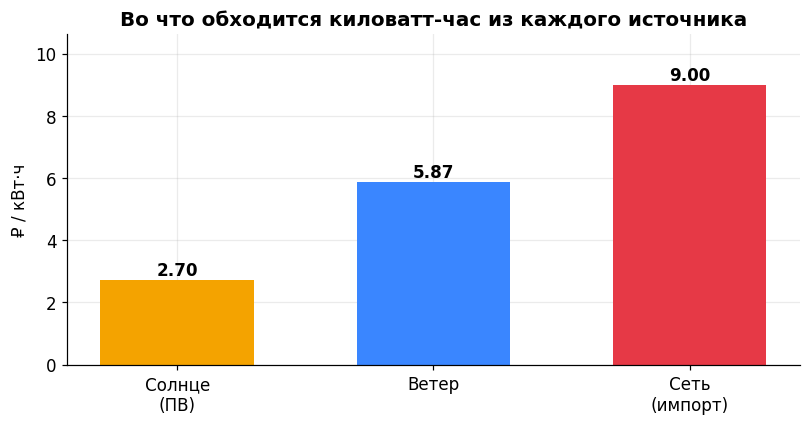


Свой киловатт‑час дешевле сетевого — но солнце светит не всегда; за это и платим батареей.


In [ ]:
r, life = 0.07, 20                        # ставка дисконта и срок службы, лет
crf = r*(1+r)**life / ((1+r)**life - 1)   # фактор возврата капитала

# --- цены по ориентирам РФ (2025-2026), все в рублях ---
capex_pv   = 60_000.0    # ₽/кВт   (сетевая ПВ-станция «под ключ»)
capex_wind = 110_000.0   # ₽/кВт   (ветроустановка «под ключ»)
capex_batt = 28_000.0    # ₽/кВт*ч (литий-ионный накопитель)
price_imp  = 9.0         # ₽/кВт*ч (тариф сети, промышленный потребитель)
duration   = 4.0         # батарея на 4 часа (мощность = ёмкость/4)
eff        = 0.95        # КПД заряда/разряда
year_scale = 8760.0 / H  # масштаб периода до года

# LCOE каждого источника = годовой платёж за 1 кВт / годовая выработка с 1 кВт
lcoe_pv   = capex_pv*crf   / (solar_cf.mean()*8760)
lcoe_wind = capex_wind*crf / (wind_cf.mean()*8760)

print(f"CRF = {crf:.4f}   (годовой платёж = CAPEX × {crf:.4f})")
print(f"Период масштабируется до года множителем {year_scale:.1f}\n")
print(f"LCOE солнца : {lcoe_pv:5.2f} ₽/кВт·ч")
print(f"LCOE ветра  : {lcoe_wind:5.2f} ₽/кВт·ч")
print(f"Тариф сети  : {price_imp:5.2f} ₽/кВт·ч")

fig, ax = plt.subplots(figsize=(7.5, 4))
names  = ['Солнце\n(ПВ)', 'Ветер', 'Сеть\n(импорт)']
vals   = [lcoe_pv, lcoe_wind, price_imp]
colors = [C['pv'], C['wind'], C['grid']]
bars = ax.bar(names, vals, color=colors, width=0.6)
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, v+0.15, f"{v:.2f}", ha='center', fontweight='bold')
ax.set_ylabel('₽ / кВт·ч'); ax.set_title('Во что обходится киловатт‑час из каждого источника')
ax.set_ylim(0, max(vals)*1.18)
plt.tight_layout(); plt.show()
print("\nСвой киловатт‑час дешевле сетевого — но солнце светит не всегда; за это и платим батареей.")


## 3. Что именно мы оптимизируем

Это центральный раздел: прежде чем запускать солвер, нужно ясно понимать **что у задачи на входе, что на выходе и по какому правилу выбирается «лучшее»**. Схема ниже — это вся модель на одной картинке.

**Каждый час** энергия течёт через общую «шину»: слева приходит (солнце, ветер, разряд батареи, импорт из сети), справа уходит (нагрузка, заряд батареи, сброс излишка). Приход обязан равняться расходу — это закон сохранения, главное физическое ограничение.

**Переменные, которые ищет солвер, двух видов:**

1. **Состав системы** (3 числа, одни на весь период) — *что построить*: мощность ПВ $P_{пв}$, мощность ветра $P_{вет}$, ёмкость батареи $E_{бат}$.
2. **Режим работы** (по 5 чисел на каждый час) — *как этим пользоваться*: заряд, разряд, состояние заряда (SoC), импорт из сети, сброс излишка.

**Цель (целевая функция):** минимизировать суммарную **годовую** стоимость = приведённые капзатраты на состав + годовой счёт за импорт из сети.


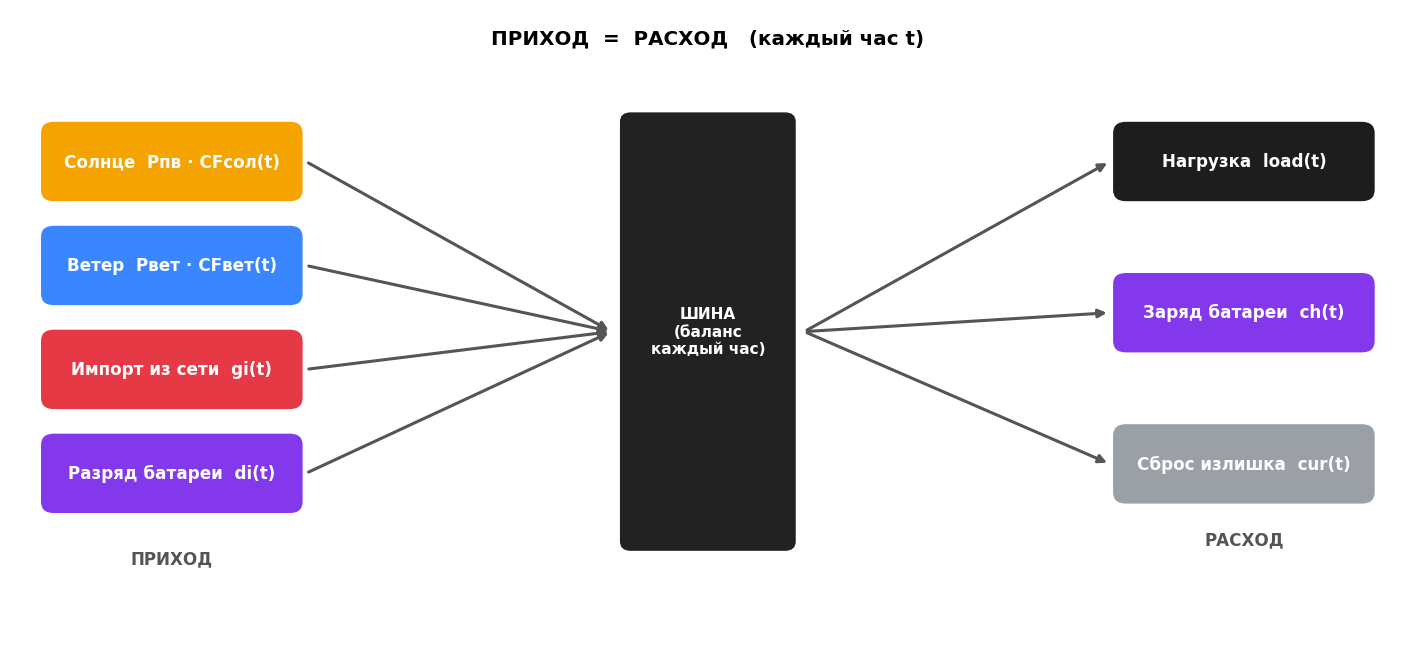

In [ ]:
# --- Схема того, что оптимизируем: потоки энергии, переменные, цель и ограничения ---
fig, ax = plt.subplots(figsize=(13, 6)); ax.axis('off')
ax.set_xlim(0, 13); ax.set_ylim(0, 6.6)

def box(x, y, w, h, text, fc, tc='white', fs=11):
    ax.add_patch(mpl.patches.FancyBboxPatch((x, y), w, h,
        boxstyle='round,pad=0.02,rounding_size=0.12', fc=fc, ec='none'))
    ax.text(x+w/2, y+h/2, text, ha='center', va='center', color=tc,
            fontsize=fs, fontweight='bold')

# центральная шина
ax.add_patch(mpl.patches.FancyBboxPatch((5.7, 0.9), 1.6, 4.6,
    boxstyle='round,pad=0.02,rounding_size=0.1', fc='#222', ec='none'))
ax.text(6.5, 3.2, 'ШИНА\n(баланс\nкаждый час)', ha='center', va='center',
        color='white', fontsize=10, fontweight='bold')

# приход (слева)
box(0.3, 4.6, 2.4, 0.8, 'Солнце  Pпв · CFсол(t)', C['pv'])
box(0.3, 3.5, 2.4, 0.8, 'Ветер  Pвет · CFвет(t)', C['wind'])
box(0.3, 2.4, 2.4, 0.8, 'Импорт из сети  gi(t)', C['grid'])
box(0.3, 1.3, 2.4, 0.8, 'Разряд батареи  di(t)', C['batt'])
# расход (справа)
box(10.3, 4.6, 2.4, 0.8, 'Нагрузка  load(t)', C['load'])
box(10.3, 3.0, 2.4, 0.8, 'Заряд батареи  ch(t)', C['batt'])
box(10.3, 1.4, 2.4, 0.8, 'Сброс излишка  cur(t)', C['curtail'])

arr = dict(arrowstyle='-|>', lw=2, color='#555')
for yy in [5.0, 3.9, 2.8, 1.7]:
    ax.annotate('', xy=(5.6, 3.2), xytext=(2.75, yy), arrowprops=arr)
for yy in [5.0, 3.4, 1.8]:
    ax.annotate('', xy=(10.25, yy), xytext=(7.4, 3.2), arrowprops=arr)

ax.text(6.5, 6.25, 'ПРИХОД  =  РАСХОД   (каждый час t)', ha='center',
        fontsize=13, fontweight='bold')
ax.text(1.5, 0.75, 'ПРИХОД', ha='center', fontsize=11, color='#555', fontweight='bold')
ax.text(11.5, 0.95, 'РАСХОД', ha='center', fontsize=11, color='#555', fontweight='bold')
plt.tight_layout(); plt.show()


### Та же модель — формально

**Переменные.** Состав: $P_{пв}, P_{вет}, E_{бат} \ge 0$. Режим в час $t$: заряд $ch_t$, разряд $di_t$, состояние заряда $soc_t$, импорт $gi_t$, сброс $cur_t \ge 0$.

**Целевая функция** (минимизируем):

$$\min\; \underbrace{\big(P_{пв}c_{пв} + P_{вет}c_{вет} + E_{бат}c_{бат}\big)\cdot \text{CRF}}_{\text{приведённые капзатраты, ₽/год}} \;+\; \underbrace{k\sum_t gi_t \cdot p_{сеть}}_{\text{счёт за сеть, ₽/год}}$$

где $c_\bullet$ — удельные CAPEX, $p_{сеть}$ — тариф, $k$ = `year_scale`.

**Ограничения для каждого часа $t$:**

$$\underbrace{P_{пв}\,CF^{сол}_t + P_{вет}\,CF^{вет}_t + di_t + gi_t}_{\text{приход}} \;=\; \underbrace{load_t + ch_t + cur_t}_{\text{расход}} \quad\text{(баланс энергии)}$$

$$soc_t = soc_{t-1} + \eta\,ch_t - di_t/\eta \quad\text{(динамика заряда, цикл замкнут: } soc_0 = soc_{H-1})$$

$$soc_t \le E_{бат}, \qquad ch_t \le E_{бат}/D, \qquad di_t \le E_{бат}/D \quad\text{(ёмкость и мощность батареи)}$$

$\eta$ — КПД, $D$ — длительность батареи (часов).

> **Важное решение модели:** доход от продажи излишка в сеть мы **не закладываем** (излишек просто сбрасывается, `cur`). Иначе задача становится **неограниченной** — выгодно строить бесконечно много панелей ради экспорта, и оптимум «улетает» в бесконечность. Это классическая ловушка таких моделей; продажу в сеть выносим в задания. Мораль: **понимай модель, а не только запускай солвер.**


## 4. Решение LP и разбор результата

Собираем задачу в `PuLP` и решаем встроенным солвером CBC. Функция `solve_sizing` принимает цену батареи (и опционально потолки мощности и порог самообеспечения) и возвращает оптимальный состав плюс полную почасовую картину работы.


In [ ]:
import pulp

def solve_sizing(cbatt, pv_max=None, wind_max=None, target_selfsuf=None):
    peak = load.max()
    pv_max   = pv_max   if pv_max   is not None else 8*peak
    wind_max = wind_max if wind_max is not None else 8*peak
    m = pulp.LpProblem("hybrid_sizing", pulp.LpMinimize)
    # --- состав (3 переменные на весь период) ---
    pv   = pulp.LpVariable("pv_cap",   0, pv_max)
    wind = pulp.LpVariable("wind_cap", 0, wind_max)
    batt = pulp.LpVariable("batt_kwh", 0)
    # --- режим (5 переменных на каждый час) ---
    ch  = [pulp.LpVariable(f"ch{t}",  0) for t in range(H)]
    di  = [pulp.LpVariable(f"di{t}",  0) for t in range(H)]
    soc = [pulp.LpVariable(f"soc{t}", 0) for t in range(H)]
    gi  = [pulp.LpVariable(f"gi{t}",  0) for t in range(H)]
    cur = [pulp.LpVariable(f"cur{t}", 0) for t in range(H)]
    # --- ограничения ---
    for t in range(H):
        m += pv*solar_cf[t] + wind*wind_cf[t] + di[t] + gi[t] == load[t] + ch[t] + cur[t]
        m += soc[t] <= batt
        m += ch[t]  <= batt/duration
        m += di[t]  <= batt/duration
        prev = soc[t-1] if t > 0 else soc[H-1]          # замкнутый цикл
        m += soc[t] == prev + eff*ch[t] - di[t]/eff
    if target_selfsuf is not None:                       # опц. порог самообеспечения
        m += pulp.lpSum(gi) <= (1-target_selfsuf)*load.sum()
    # --- цель: годовые капзатраты + годовой счёт за сеть ---
    m += (pv*capex_pv*crf + wind*capex_wind*crf + batt*cbatt*crf
          + year_scale*pulp.lpSum(gi[t]*price_imp for t in range(H)))
    m.solve(pulp.PULP_CBC_CMD(msg=0))
    imp = np.array([gi[t].value() for t in range(H)])
    return {
        "status": pulp.LpStatus[m.status],
        "pv": pv.value(), "wind": wind.value(), "batt": batt.value(),
        "cost": pulp.value(m.objective),
        "self_suf": 1 - imp.sum()/load.sum(),
        "cap_pv":   pv.value()*capex_pv*crf,
        "cap_wind": wind.value()*capex_wind*crf,
        "cap_batt": batt.value()*cbatt*crf,
        "grid_cost": year_scale*imp.sum()*price_imp,
        "pv_gen": pv.value()*solar_cf, "wind_gen": wind.value()*wind_cf,
        "charge": np.array([ch[t].value() for t in range(H)]),
        "discharge": np.array([di[t].value() for t in range(H)]),
        "soc": np.array([soc[t].value() for t in range(H)]),
        "grid": imp, "curtail": np.array([cur[t].value() for t in range(H)]),
    }

sol = solve_sizing(capex_batt)
print("Статус:", sol["status"])
print("\nОптимальный состав:")
print(f"   ПВ:        {sol['pv']:8.0f} кВт")
print(f"   ветер:     {sol['wind']:8.0f} кВт")
print(f"   батарея:   {sol['batt']:8.0f} кВт·ч  (мощность {sol['batt']/duration:.0f} кВт)")
print(f"\nГодовая стоимость: {rub(sol['cost'])}")
print(f"Самообеспечение:   {sol['self_suf']*100:.1f}%   (остальное — импорт из сети)")


Статус: Optimal

Оптимальный состав:
   ПВ:            1794 кВт
   ветер:         4078 кВт
   батарея:       2652 кВт·ч  (мощность 663 кВт)

Годовая стоимость: 78.1 млн ₽
Самообеспечение:   82.9%   (остальное — импорт из сети)


### Куда уходят деньги и откуда берётся энергия

Два разреза одного решения. **Слева** — из чего складывается годовая стоимость (₽/год): сколько на каждую технологию и сколько на сеть. **В центре** — оптимальный состав в «железе» (кВт и кВт·ч). **Справа** — годовой баланс энергии: какую долю спроса закрыли солнце, ветер, батарея и сеть. Самообеспечение = всё, кроме красного «сеть».


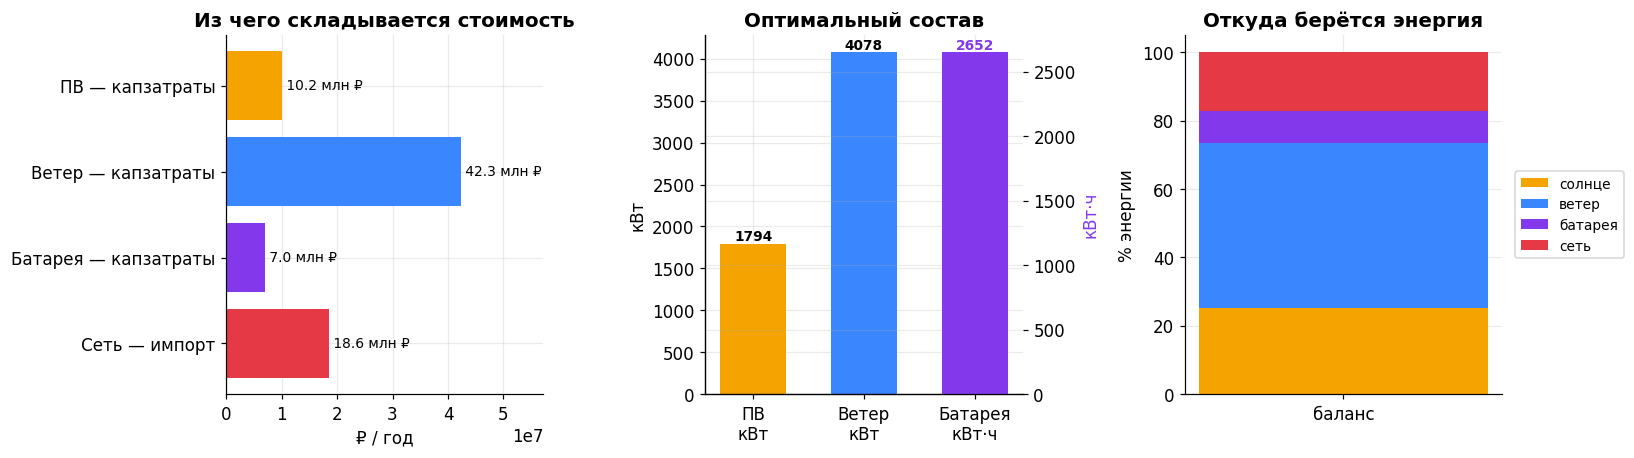

In [ ]:
fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(15, 4.3))

# (1) разбор стоимости — горизонтальные полосы
items = [('ПВ — капзатраты', sol['cap_pv'], C['pv']),
         ('Ветер — капзатраты', sol['cap_wind'], C['wind']),
         ('Батарея — капзатраты', sol['cap_batt'], C['batt']),
         ('Сеть — импорт', sol['grid_cost'], C['grid'])]
labels = [i[0] for i in items]; vals = [i[1] for i in items]; cols = [i[2] for i in items]
a1.barh(labels, vals, color=cols)
for y,v in enumerate(vals): a1.text(v, y, ' '+rub(v), va='center', fontsize=9)
a1.invert_yaxis(); a1.set_xlabel('₽ / год'); a1.set_title('Из чего складывается стоимость')
a1.set_xlim(0, max(vals)*1.35)

# (2) состав системы
a2.bar(['ПВ\nкВт','Ветер\nкВт'], [sol['pv'], sol['wind']], color=[C['pv'],C['wind']], width=.6)
a2.set_ylabel('кВт'); a2.set_title('Оптимальный состав')
a2b = a2.twinx()
a2b.bar(['Батарея\nкВт·ч'], [sol['batt']], color=C['batt'], width=.6)
a2b.set_ylabel('кВт·ч', color=C['batt'])
for i,(lab,v) in enumerate([('',sol['pv']),('',sol['wind'])]):
    a2.text(i, v, f'{v:.0f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
a2b.text(2, sol['batt'], f"{sol['batt']:.0f}", ha='center', va='bottom', fontweight='bold', fontsize=9, color=C['batt'])

# (3) баланс энергии: чем покрыт спрос за период (суммы точно дают 100%)
#     спрос = (ВИЭ напрямую) + (разряд батареи) + (импорт), без двойного счёта
res_direct = load.sum() - sol['discharge'].sum() - sol['grid'].sum()
gp, gw = sol['pv_gen'].sum(), sol['wind_gen'].sum()
pv_to_load   = res_direct * gp/(gp+gw)     # прямой вклад ВИЭ делим по выработке
wind_to_load = res_direct * gw/(gp+gw)
shares = np.array([pv_to_load, wind_to_load, sol['discharge'].sum(), sol['grid'].sum()])
shares = shares/load.sum()*100
a3.bar(['баланс'], [shares[0]], color=C['pv'], label='солнце')
a3.bar(['баланс'], [shares[1]], bottom=shares[0], color=C['wind'], label='ветер')
a3.bar(['баланс'], [shares[2]], bottom=shares[:2].sum(), color=C['batt'], label='батарея')
a3.bar(['баланс'], [shares[3]], bottom=shares[:3].sum(), color=C['grid'], label='сеть')
a3.set_ylabel('% энергии'); a3.set_title('Откуда берётся энергия')
a3.legend(loc='center left', bbox_to_anchor=(1.02,0.5), fontsize=9)
plt.tight_layout(); plt.show()


### В чём, собственно, выигрыш? Сравним с «купить всё из сети»

Оптимизация имеет смысл только относительно альтернативы. Самая простая альтернатива — **ничего не строить и весь спрос покрывать импортом** по тарифу сети. Сравним её годовую стоимость с найденным гибридом — это и есть «цена» оптимального решения и его экономия.


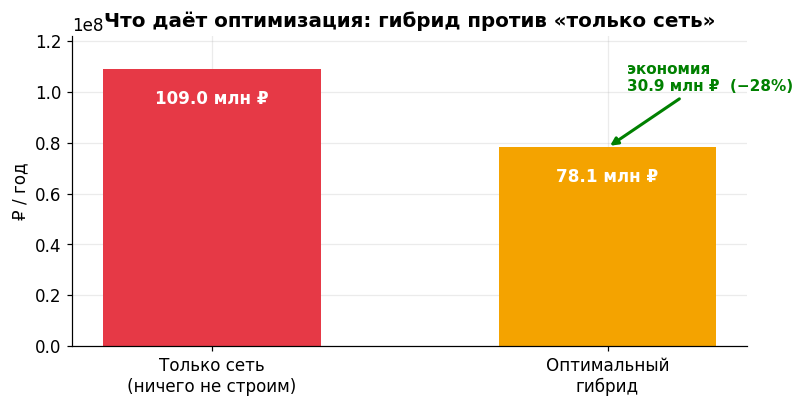

Только сеть:           109,000,590 ₽/год
Оптимальный гибрид:     78,122,228 ₽/год
Экономия:               30,878,362 ₽/год  (28%)


In [ ]:
grid_only = year_scale * load.sum() * price_imp     # если бы всё покупали из сети
hybrid    = sol['cost']
saving    = grid_only - hybrid

fig, ax = plt.subplots(figsize=(7.5, 4))
bars = ax.bar(['Только сеть\n(ничего не строим)', 'Оптимальный\nгибрид'],
              [grid_only, hybrid], color=[C['grid'], C['pv']], width=0.55)
for b, v in zip(bars, [grid_only, hybrid]):
    ax.text(b.get_x()+b.get_width()/2, v, '\n'+rub(v), ha='center', va='top',
            color='white', fontweight='bold')
ax.annotate(f'экономия\n{rub(saving)}  (−{saving/grid_only*100:.0f}%)',
            xy=(1, hybrid), xytext=(1.05, grid_only*0.92),
            fontsize=10, fontweight='bold', color='green',
            arrowprops=dict(arrowstyle='-|>', color='green', lw=2))
ax.set_ylabel('₽ / год'); ax.set_title('Что даёт оптимизация: гибрид против «только сеть»')
ax.set_ylim(0, grid_only*1.12)
plt.tight_layout(); plt.show()

print(f"Только сеть:        {grid_only:>14,.0f} ₽/год")
print(f"Оптимальный гибрид: {hybrid:>14,.0f} ₽/год")
print(f"Экономия:           {saving:>14,.0f} ₽/год  ({saving/grid_only*100:.0f}%)")


## 5. Диспетчеризация: как система живёт по часам

Состав найден — теперь смотрим, **как** LP им распоряжается во времени. На верхнем графике видно базовую логику покрытия нагрузки: днём солнце и ветер закрывают спрос и заряжают батарею, вечером батарея разряжается на пик, а сеть подхватывает то, что не закрыли свои источники. Нижний график — состояние заряда батареи (SoC): характерная «пила» — заряд днём, разряд вечером.


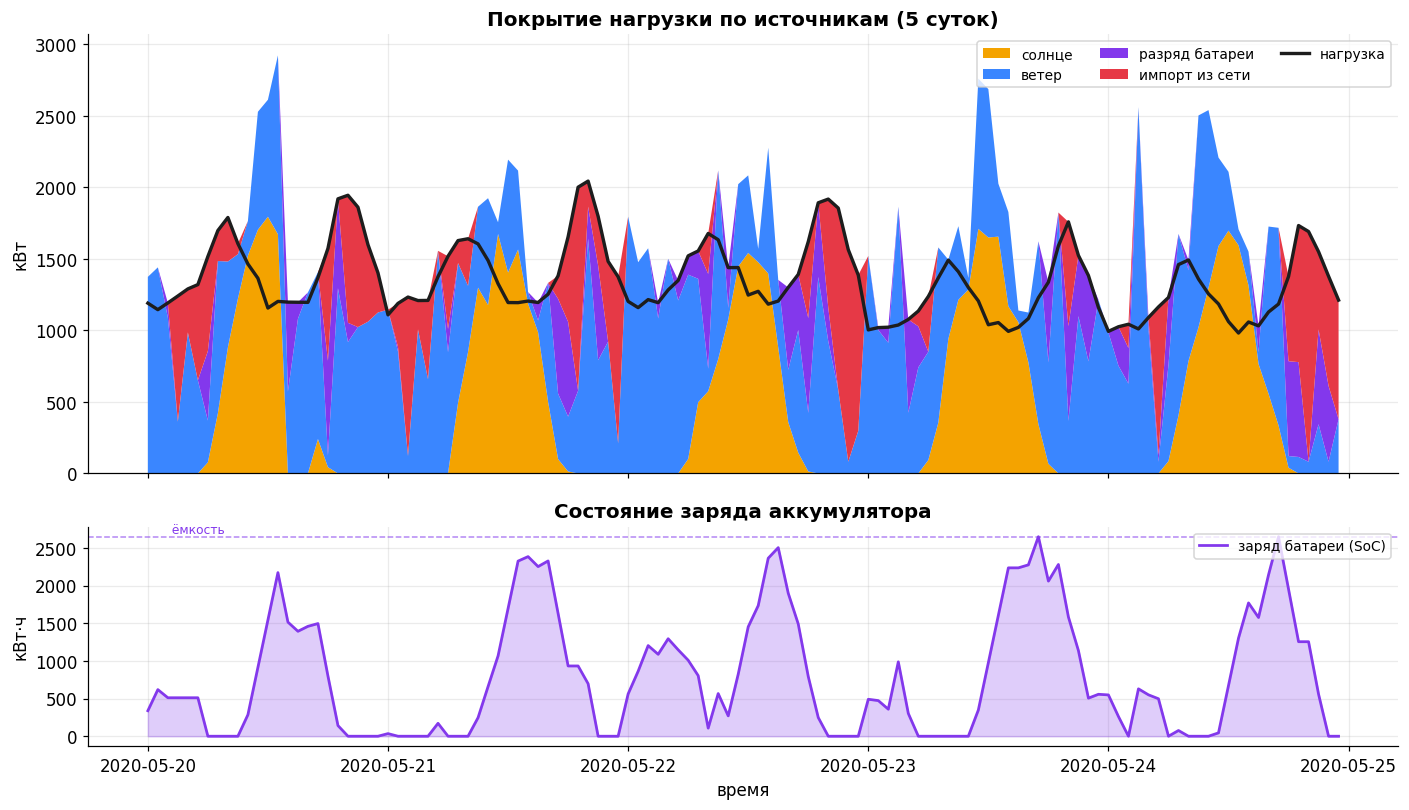

In [ ]:
s, e = 24*5, 24*10     # окно в 5 дней
t = idx[s:e]
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7.5), sharex=True,
                               gridspec_kw={'height_ratios':[2,1]})

ax1.stackplot(t, sol['pv_gen'][s:e], sol['wind_gen'][s:e], sol['discharge'][s:e], sol['grid'][s:e],
              labels=['солнце','ветер','разряд батареи','импорт из сети'],
              colors=[C['pv'], C['wind'], C['batt'], C['grid']])
ax1.plot(t, load[s:e], color=C['load'], lw=2.2, label='нагрузка')
ax1.set_ylabel('кВт'); ax1.legend(loc='upper right', ncol=3, fontsize=9)
ax1.set_title('Покрытие нагрузки по источникам (5 суток)')

ax2.fill_between(t, 0, sol['soc'][s:e], color=C['batt'], alpha=.25)
ax2.plot(t, sol['soc'][s:e], color=C['batt'], lw=1.8, label='заряд батареи (SoC)')
ax2.axhline(sol['batt'], color=C['batt'], ls='--', lw=1, alpha=.6)
ax2.text(t[2], sol['batt'], ' ёмкость', va='bottom', fontsize=8, color=C['batt'])
ax2.set_ylabel('кВт·ч'); ax2.set_xlabel('время'); ax2.legend(loc='upper right', fontsize=9)
ax2.set_title('Состояние заряда аккумулятора')
plt.tight_layout(); plt.show()


## 6. Чувствительность к цене аккумулятора

Главный системный вопрос: **что меняется, когда хранение дешевеет?** Перерешаем задачу при разных ценах батареи и смотрим, как сдвигается оптимальный состав и самообеспечение.

Здесь прячется самый интересный результат всего занятия. Ожидаемое: дешевле батарея → больше хранения и выше самообеспечение. Неожиданное: при **очень дешёвом** хранении оптимум **полностью отказывается от ветра** в пользу переизбытка дешёвого солнца — потому что лишнюю дневную энергию теперь дёшево запасти на вечер. Экономика хранения буквально **переворачивает выбор технологий**.


батарея 55,000 ₽/кВт·ч  ->  ПВ=  1612  ветер=  3226  батарея=       0 кВт·ч  самообесп=  66%
батарея 40,000 ₽/кВт·ч  ->  ПВ=  1621  ветер=  3532  батарея=     618 кВт·ч  самообесп=  71%
батарея 28,000 ₽/кВт·ч  ->  ПВ=  1794  ветер=  4078  батарея=    2652 кВт·ч  самообесп=  83%
батарея 18,000 ₽/кВт·ч  ->  ПВ=  3241  ветер=  3203  батарея=    8795 кВт·ч  самообесп=  94%
батарея  9,000 ₽/кВт·ч  ->  ПВ=  6206  ветер=     0  батарея=   20742 кВт·ч  самообесп=  95%
батарея  4,500 ₽/кВт·ч  ->  ПВ=  6223  ветер=     0  батарея=   24622 кВт·ч  самообесп=  96%


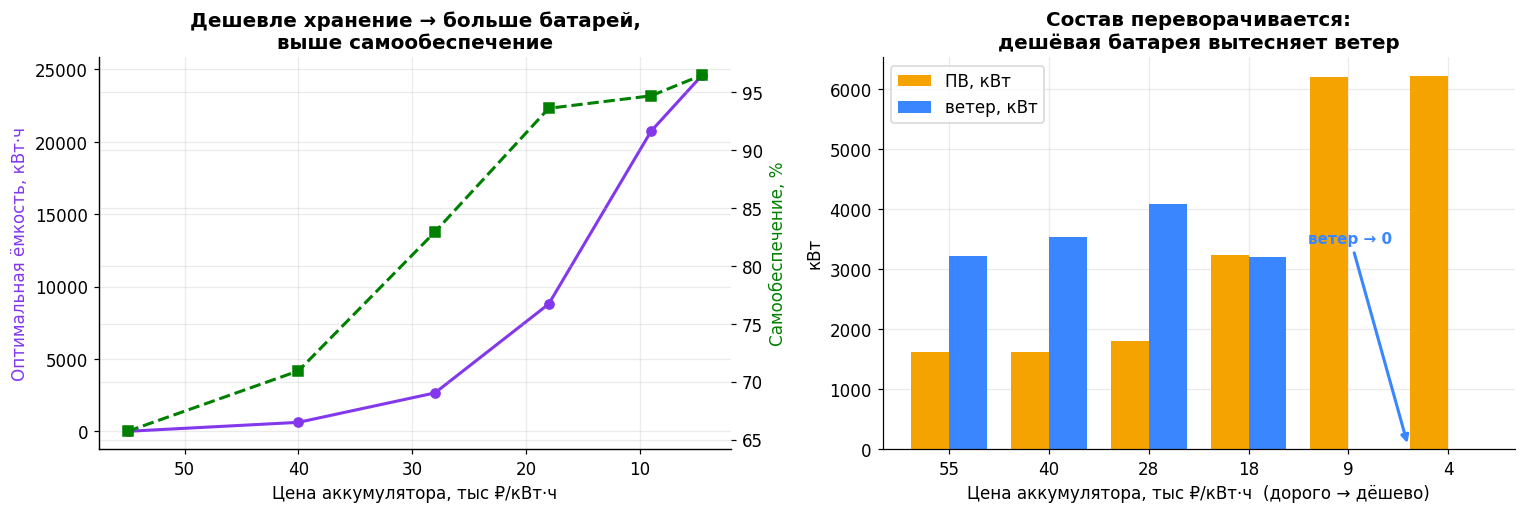

In [ ]:
batt_prices = [55_000, 40_000, 28_000, 18_000, 9_000, 4_500]   # ₽/кВт·ч: дорого -> дёшево
rows = []
for cb in batt_prices:
    s = solve_sizing(float(cb))
    rows.append((cb, s['pv'], s['wind'], s['batt'], s['self_suf']*100, s['cost']))
    print(f"батарея {cb:>6,} ₽/кВт·ч  ->  ПВ={s['pv']:6.0f}  ветер={s['wind']:6.0f}  "
          f"батарея={s['batt']:8.0f} кВт·ч  самообесп={s['self_suf']*100:4.0f}%")

cb_arr   = [r[0]/1000 for r in rows]   # тыс ₽
pv_arr   = [r[1] for r in rows]
wind_arr = [r[2] for r in rows]
batt_arr = [r[3] for r in rows]
self_arr = [r[4] for r in rows]

fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 4.8))

# (1) ёмкость батареи и самообеспечение vs цена
axL.plot(cb_arr, batt_arr, 'o-', color=C['batt'], lw=2, label='ёмкость батареи')
axL.set_xlabel('Цена аккумулятора, тыс ₽/кВт·ч')
axL.set_ylabel('Оптимальная ёмкость, кВт·ч', color=C['batt'])
axL.invert_xaxis()
axLb = axL.twinx()
axLb.plot(cb_arr, self_arr, 's--', color='green', lw=2, label='самообеспечение')
axLb.set_ylabel('Самообеспечение, %', color='green')
axL.set_title('Дешевле хранение → больше батарей,\nвыше самообеспечение')

# (2) сдвиг состава: ПВ vs ветер -> видно, как ветер исчезает
x = np.arange(len(cb_arr)); w = 0.38
axR.bar(x-w/2, pv_arr,   w, color=C['pv'],   label='ПВ, кВт')
axR.bar(x+w/2, wind_arr, w, color=C['wind'], label='ветер, кВт')
axR.set_xticks(x); axR.set_xticklabels([f'{c:.0f}' for c in cb_arr])
axR.set_xlabel('Цена аккумулятора, тыс ₽/кВт·ч  (дорого → дёшево)')
axR.set_ylabel('кВт'); axR.legend()
axR.set_title('Состав переворачивается:\nдешёвая батарея вытесняет ветер')
axR.annotate('ветер → 0', xy=(4.6, 50), xytext=(3.6, max(pv_arr)*0.55),
             fontsize=10, fontweight='bold', color=C['wind'],
             arrowprops=dict(arrowstyle='-|>', color=C['wind'], lw=2))
plt.tight_layout(); plt.show()


## 7. Что мы поняли и задания

- **Проектирование как оптимизация.** Состав системы и режим её работы можно найти строго — линейным программированием, минимизируя стоимость при физических ограничениях. Это другой инструмент, чем ML всего курса.
- **Кирпичики сходятся вместе.** Солнце (из реального Plant_1), ветер и аккумулятор впервые работают как одна система: солнце и ветер дополняют друг друга по времени, батарея сдвигает энергию с пика генерации на пик спроса.
- **В чём выигрыш — измеримо.** Гибрид дешевле сценария «только сеть»; сравнение даёт конкретную годовую экономию в рублях, а не абстрактную «зелёность».
- **Экономика решает.** Оптимальный состав определяется ценами: дешевле хранение — больше батарей и выше самообеспечение, а при очень дешёвой батарее ветер вытесняется переизбытком солнца. Анализ чувствительности показывает это количественно.
- **Ловушки формулировки.** Доход от экспорта без ограничений делает задачу неограниченной — поэтому важно понимать модель, а не только запускать солвер.

### Задания
1. **Порог самообеспечения.** Вызовите `solve_sizing(capex_batt, target_selfsuf=0.95)` и посмотрите, как вырастет стоимость ради независимости от сети. Постройте кривую «стоимость vs требуемое самообеспечение».
2. **Продажа в сеть.** Добавьте доход от экспорта с ценой строго ниже импортной и с верхним пределом мощности экспорта. При какой цене задача снова станет осмысленной (ограниченной)?
3. **Зонный тариф / дорогая сеть.** Сделайте `price_imp` зависящим от часа (день/ночь, пик/полупик/ночь по тарифам РФ) или просто поднимите его. Как это сдвигает состав в сторону ВИЭ и батареи и как растёт ценность хранения?
4. **Реальный ветер.** Замените модельный ветер на реальный профиль скорости ветра (например, open‑meteo — отдаёт скорость ветра без токена). Меняются ли выводы?
5. **Мощность батареи отдельно.** Сейчас мощность батареи привязана к ёмкости (4 часа, параметр `duration`). Сделайте мощность отдельной переменной со своей ценой (₽/кВт) — как изменится оптимум при «длинных» и «коротких» батареях?
